# RFP 데이터 EDA

`data/raw`에 저장된 RFP 메타데이터와 추출된 문서 텍스트를 탐색합니다.

확인 항목:
- 메타데이터와 원본 파일 목록 로드
- 파일 매칭, 결측치, 중복 값 검증
- 발주기관, 파일 형식, 사업금액, 공고일과 마감일, 텍스트 길이 분석
- 추가 NLP 의존성 없이 간단한 빈출어 추출
- 이후 RAG 메타데이터 필터로 사용할 RFP 키워드 그룹 생성

분석에 필요한 라이브러리와 경로를 설정합니다.

In [1]:
from pathlib import Path
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

plt.rcParams["font.family"] = ["Malgun Gothic", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "raw"
FILES_DIR = DATA_DIR / "files"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "eda"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH = DATA_DIR / "data_list.csv"
XLSX_PATH = DATA_DIR / "data_list.xlsx"

PROJECT_ROOT, DATA_DIR, FILES_DIR, OUTPUT_DIR

(WindowsPath('c:/Users/jgi01/Desktop/codeit_project_2'),
 WindowsPath('c:/Users/jgi01/Desktop/codeit_project_2/data/raw'),
 WindowsPath('c:/Users/jgi01/Desktop/codeit_project_2/data/raw/files'),
 WindowsPath('c:/Users/jgi01/Desktop/codeit_project_2/outputs/eda'))

## 1. 메타데이터 로드

CSV를 우선 읽고, 인코딩 문제가 있으면 여러 인코딩을 순차적으로 시도합니다.

In [2]:
def read_metadata(csv_path: Path, xlsx_path: Path | None = None) -> pd.DataFrame:
    encodings = ["utf-8-sig", "utf-8", "cp949", "euc-kr"]
    last_error = None
    for enc in encodings:
        try:
            return pd.read_csv(csv_path, encoding=enc)
        except UnicodeDecodeError as exc:
            last_error = exc
    if xlsx_path and xlsx_path.exists():
        return pd.read_excel(xlsx_path)
    raise last_error

rfp = read_metadata(CSV_PATH, XLSX_PATH)
print(f"메타데이터 크기: {rfp.shape[0]:,}행 x {rfp.shape[1]:,}열")
display(rfp.head(3))
rfp.info()

메타데이터 크기: 100행 x 12열


,공고 번호,공고 차수,사업명,사업 금액,발주 기관,공개 일자,입찰 참여 시작일,입찰 참여 마감일,사업 요약,파일형식,파일명,텍스트
0,20241001798,0.00,한영대학교 특성화 맞춤형 교육환경 구축 - 트랙운영 학사정보시스템 고도화,"130,000,000.00",한영대학,2024-10-04 13:51:23,NaN,2024-10-15 17:00:00,- 한영대학교 특성화 맞춤형 교육환경 구축을 위해 트랙운영 학사정보시스템을 고도화한다.\n- 트랙제도를 도입하여 다양한 진로 선택 기회를 제공하고 산업현장의 경쟁력을 강화한다.\n- 효과적인 교육과정 지원 및...,hwp,한영대학_한영대학교 특성화 맞춤형 교육환경 구축 - 트랙운영 학사정보.hwp,\n \n2024년 특성화 맞춤형 교육환경 구축 – 트랙운영 학사정보시스템 고도화\n 제안요청서\n\n2024. 10.\n \n \n \n목 차\nⅠ. 사업 안내 - ...
1,20241002912,0.00,2024년 대학산학협력활동 실태조사 시스템(UICC) 기능개선,"129,300,000.00",한국연구재단,2024-10-04 15:01:52,2024-10-14 10:00:00,2024-10-16 14:00:00,- 사업 개요: 2024년 대학 산학협력활동 실태조사 시스템(UICC) 기능개선\n- 추진배경: 대학 산학협력활동 실태조사를 안정적으로 운영하고 사용자 편의성을 개선하기 위해 필요\n- 사업범위: UICC 시...,hwp,한국연구재단_2024년 대학산학협력활동 실태조사 시스템(UICC) 기능개선.hwp,\r\n \r\n \r\n \r\n제 안 요 청 서\r\n[ 2024년 대학 산학협력활동 실태조사 시스템(UICC) 기능개선 ]\r\n2024. 10.\r\n \r\n담 당\r\n부 서 명\r\n성...
2,20240827859,0.00,EIP3.0 고압가스 안전관리 시스템 구축 용역,"40,000,000.00",한국생산기술연구원,2024-08-28 11:31:02,2024-08-29 09:00:00,2024-09-09 10:00:00,"- 사업 개요: EIP3.0 고압가스 안전관리 시스템 구축 용역\n- 추진배경: 안전사고 증가, 법적 요구사항, 연구 환경 보호에 대한 필요성\n- 사업범위: 화학물질 운영현황 통계 정보 제공, 고압가스 화학...",hwp,한국생산기술연구원_EIP3.0 고압가스 안전관리 시스템 구축 용역.hwp,\r\n \r\nEIP3.0 고압가스 안전관리\r\n시스템 구축 용역\r\n2024. 08.\r\n \r\n디지털행정추진실\r\n한국생산기술연구원\r\n \r\n담당\r\n사양 및 과업\r\n디지...


<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   공고 번호      82 non-null     str    
 1   공고 차수      82 non-null     float64
 2   사업명        100 non-null    str    
 3   사업 금액      99 non-null     float64
 4   발주 기관      100 non-null    str    
 5   공개 일자      100 non-null    str    
 6   입찰 참여 시작일  74 non-null     str    
 7   입찰 참여 마감일  92 non-null     str    
 8   사업 요약      100 non-null    str    
 9   파일형식       100 non-null    str    
 10  파일명        100 non-null    str    
 11  텍스트        100 non-null    str    
dtypes: float64(2), str(10)
memory usage: 9.5 KB


원본 컬럼명을 위치 기준 변수로 매핑해 이후 코드에서 일관되게 사용합니다.

In [3]:
# 콘솔/소스 인코딩 문제에 흔들리지 않도록 위치 기준으로 컬럼을 매핑합니다.
# 원본 컬럼:
# 0 공고번호, 1 공고차수, 2 사업명, 3 예산, 4 발주기관,
# 5 공고일, 6 입찰 시작일, 7 입찰 마감일, 8 요약, 9 파일 형식, 10 파일명, 11 추출 텍스트
(
    COL_NOTICE_ID,
    COL_ROUND,
    COL_TITLE,
    COL_AMOUNT,
    COL_ORG,
    COL_PUBLISHED_AT,
    COL_BID_START,
    COL_BID_END,
    COL_SUMMARY,
    COL_FILE_TYPE,
    COL_FILE_NAME,
    COL_TEXT,
) = rfp.columns[:12]

rfp.columns.tolist()

['공고 번호',
 '공고 차수',
 '사업명',
 '사업 금액',
 '발주 기관',
 '공개 일자',
 '입찰 참여 시작일',
 '입찰 참여 마감일',
 '사업 요약',
 '파일형식',
 '파일명',
 '텍스트']

## 2. 원본 파일 목록과 메타데이터 매칭

`data/raw/files`에 있는 실제 RFP 파일이 메타데이터의 `파일명`과 정상적으로 연결되는지 확인합니다.

원본 파일 목록의 파일명, 확장자, 크기, 경로를 표로 정리합니다.

원본 파일 수: 101


,file_name,ext,file_size_mb,path
0,(사)벤처기업협회_2024년 벤처확인종합관리시스템 기능 고도화 용역사업 .hwp,hwp,4.07,data\raw\files\(사)벤처기업협회_2024년 벤처확인종합관리시스템 기능 고도화 용역사업 .hwp
1,(사)부산국제영화제_2024년 BIFF & ACFM 온라인서비스 재개발 및 행사지원시.hwp,hwp,0.27,data\raw\files\(사)부산국제영화제_2024년 BIFF & ACFM 온라인서비스 재개발 및 행사지원시.hwp
2,(사）한국대학스포츠협의회_KUSF 체육특기자 경기기록 관리시스템 개발.hwp,hwp,0.86,data\raw\files\(사）한국대학스포츠협의회_KUSF 체육특기자 경기기록 관리시스템 개발.hwp
3,(재)예술경영지원센터_통합 정보시스템 구축 사전 컨설팅.hwp,hwp,1.11,data\raw\files\(재)예술경영지원센터_통합 정보시스템 구축 사전 컨설팅.hwp
4,2025 구미 아시아육상경기선수권대회 조직위원회_2025 구미아시아육상경.hwp,hwp,0.23,data\raw\files\2025 구미 아시아육상경기선수권대회 조직위원회_2025 구미아시아육상경.hwp


,ext,file_count
0,hwp,96
1,pdf,4
2,docx,1


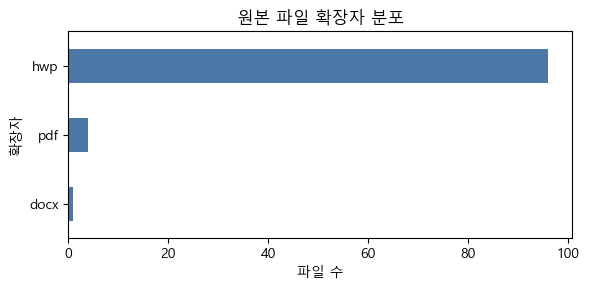

In [4]:
files = sorted([p for p in FILES_DIR.glob("*") if p.is_file()])
files_df = pd.DataFrame({
    "file_name": [p.name for p in files],
    "ext": [p.suffix.lower().lstrip(".") for p in files],
    "file_size_mb": [p.stat().st_size / 1024 / 1024 for p in files],
    "path": [str(p.relative_to(PROJECT_ROOT)) for p in files],
})

print(f"원본 파일 수: {len(files_df):,}")
display(files_df.head())
display(files_df["ext"].value_counts().rename_axis("ext").reset_index(name="file_count"))

fig, ax = plt.subplots(figsize=(6, 3))
files_df["ext"].value_counts().sort_values().plot(kind="barh", ax=ax, color="#4C78A8")
ax.set_title("원본 파일 확장자 분포")
ax.set_xlabel("파일 수")
ax.set_ylabel("확장자")
plt.tight_layout()

날짜, 금액, 텍스트 길이 같은 분석용 파생 변수를 만들고 원본 파일과 매칭합니다.

In [5]:
eda = rfp.copy()

for col in [COL_PUBLISHED_AT, COL_BID_START, COL_BID_END]:
    eda[col] = pd.to_datetime(eda[col], errors="coerce")

eda[COL_AMOUNT] = pd.to_numeric(eda[COL_AMOUNT], errors="coerce")
eda["file_name"] = eda[COL_FILE_NAME].astype(str).str.strip()
eda["file_ext_from_name"] = eda["file_name"].str.extract(r"\.([^.]+)$", expand=False).str.lower()
eda["summary_chars"] = eda[COL_SUMMARY].fillna("").astype(str).str.len()
eda["text_chars"] = eda[COL_TEXT].fillna("").astype(str).str.len()
eda["title_chars"] = eda[COL_TITLE].fillna("").astype(str).str.len()
eda["bid_window_days"] = (eda[COL_BID_END] - eda[COL_BID_START]).dt.total_seconds() / 86400
eda["publish_to_deadline_days"] = (eda[COL_BID_END] - eda[COL_PUBLISHED_AT]).dt.total_seconds() / 86400

eda = eda.merge(
    files_df[["file_name", "ext", "file_size_mb", "path"]],
    on="file_name",
    how="left",
    validate="m:1",
)
eda["file_exists"] = eda["path"].notna()

match_summary = pd.DataFrame({
    "metric": ["metadata_rows", "source_files", "matched_files", "unmatched_metadata_rows", "extra_source_files"],
    "value": [
        len(eda),
        len(files_df),
        int(eda["file_exists"].sum()),
        int((~eda["file_exists"]).sum()),
        int((~files_df["file_name"].isin(eda["file_name"])).sum()),
    ],
})
display(match_summary)

if (~eda["file_exists"]).any():
    display(eda.loc[~eda["file_exists"], [COL_TITLE, COL_ORG, COL_FILE_NAME]].head(20))

extra_files = files_df.loc[~files_df["file_name"].isin(eda["file_name"])]
if len(extra_files):
    display(extra_files)

,metric,value
0,metadata_rows,100
1,source_files,101
2,matched_files,100
3,unmatched_metadata_rows,0
4,extra_source_files,1


,file_name,ext,file_size_mb,path
12,고려대학교_차세대 포털·학사 정보시스템 구축사업.docx,docx,0.44,data\raw\files\고려대학교_차세대 포털·학사 정보시스템 구축사업.docx


## 3. 데이터 품질 점검

결측치, 중복, 비어 있는 본문 텍스트처럼 이후 분석과 RAG 인덱싱에 영향을 줄 수 있는 항목을 확인합니다.

결측치와 중복 여부를 확인해 데이터 품질 이슈를 점검합니다.

In [6]:
missing = (
    eda.isna().sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_rate=lambda x: x["missing_count"] / len(eda))
    .sort_values("missing_count", ascending=False)
)
display(missing)

quality_summary = pd.DataFrame({
    "check": ["notice_id_round_duplicate_rows", "file_name_duplicate_rows", "text_duplicate_rows", "amount_missing", "empty_text"],
    "rows": [
        int(eda.duplicated(subset=[COL_NOTICE_ID, COL_ROUND], keep=False).sum()),
        int(eda.duplicated(subset=[COL_FILE_NAME], keep=False).sum()),
        int(eda.duplicated(subset=[COL_TEXT], keep=False).sum()),
        int(eda[COL_AMOUNT].isna().sum()),
        int((eda[COL_TEXT].fillna("").str.strip() == "").sum()),
    ],
})
display(quality_summary)

if quality_summary.loc[quality_summary["check"].eq("file_name_duplicate_rows"), "rows"].iloc[0] > 0:
    display(
        eda.loc[eda.duplicated(subset=[COL_FILE_NAME], keep=False),
                [COL_NOTICE_ID, COL_ROUND, COL_TITLE, COL_ORG, COL_FILE_NAME]]
        .sort_values(COL_FILE_NAME)
    )

,missing_count,missing_rate
입찰 참여 시작일,26,0.26
bid_window_days,26,0.26
공고 차수,18,0.18
공고 번호,18,0.18
입찰 참여 마감일,8,0.08
publish_to_deadline_days,8,0.08
사업 금액,1,0.01
공개 일자,0,0.00
발주 기관,0,0.00
사업명,0,0.00


,check,rows
0,notice_id_round_duplicate_rows,18
1,file_name_duplicate_rows,0
2,text_duplicate_rows,0
3,amount_missing,1
4,empty_text,0


## 4. 발주기관과 파일 형식 분포

어떤 기관의 RFP가 많이 포함되어 있는지, 문서 형식은 어떻게 구성되어 있는지 살펴봅니다.

전체 규모와 상위 발주기관, 파일 형식 분포를 요약합니다.

,metric,value
0,rfp_count,100.00
1,organization_count,87.00
2,file_type_count,2.00
3,total_file_size_mb,162.88
4,budget_total_100m_krw,683.77
5,budget_median_100m_krw,1.73
6,text_chars_median,"2,583.00"


,organization,rfp_count
0,한국수자원공사,3
1,한국철도공사 (용역),3
2,한국연구재단,2
3,한국생산기술연구원,2
4,인천광역시,2
5,국방과학연구소,2
6,수협중앙회,2
7,한국농어촌공사,2
8,축산물품질평가원,2
9,광주과학기술원,2


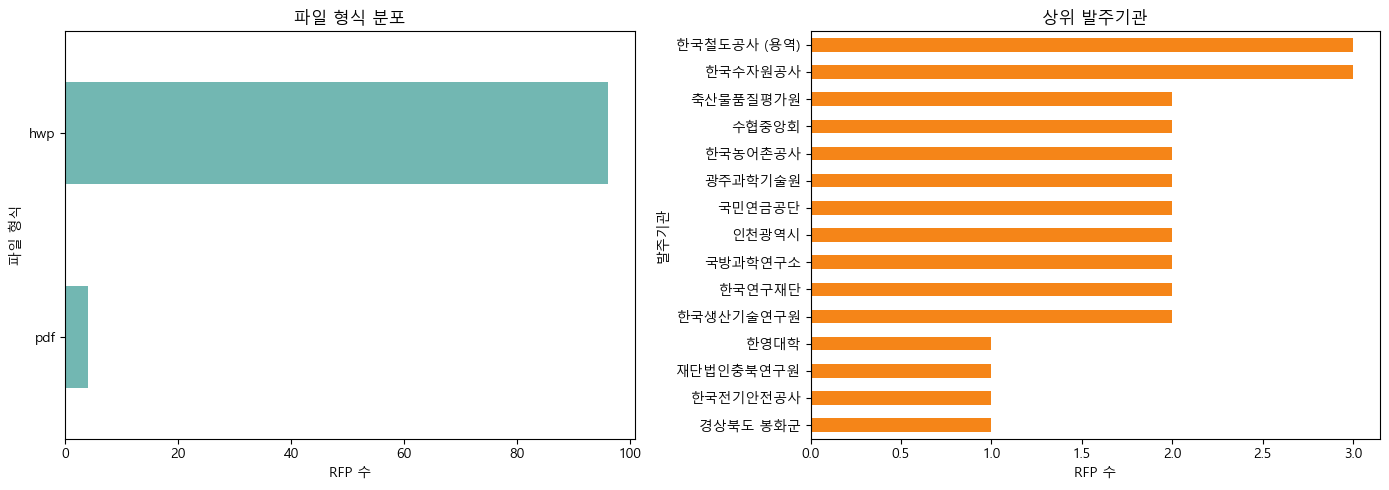

In [7]:
summary = pd.DataFrame({
    "metric": [
        "rfp_count", "organization_count", "file_type_count", "total_file_size_mb",
        "budget_total_100m_krw", "budget_median_100m_krw", "text_chars_median"
    ],
    "value": [
        len(eda),
        eda[COL_ORG].nunique(),
        eda[COL_FILE_TYPE].nunique(),
        eda["file_size_mb"].sum(),
        eda[COL_AMOUNT].sum() / 100_000_000,
        eda[COL_AMOUNT].median() / 100_000_000,
        eda["text_chars"].median(),
    ],
})
display(summary)

top_orgs = eda[COL_ORG].value_counts().head(15)
display(top_orgs.rename_axis("organization").reset_index(name="rfp_count"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
eda[COL_FILE_TYPE].value_counts().sort_values().plot(kind="barh", ax=axes[0], color="#72B7B2")
axes[0].set_title("파일 형식 분포")
axes[0].set_xlabel("RFP 수")
axes[0].set_ylabel("파일 형식")

top_orgs.sort_values().plot(kind="barh", ax=axes[1], color="#F58518")
axes[1].set_title("상위 발주기관")
axes[1].set_xlabel("RFP 수")
axes[1].set_ylabel("발주기관")
plt.tight_layout()

## 5. 사업금액 분석

사업금액의 전체 분포와 상위 금액 RFP를 확인합니다. 금액이 0원인 행이 있어 로그 분포에는 양수 금액만 사용합니다.

사업금액의 통계량, 상위 금액 사업, 분포를 확인합니다.

,krw,100m_krw
count,99.00,0.00
mean,"690,671,979.68",6.91
std,"1,966,690,585.92",19.67
min,0.00,0.00
10%,"43,800,000.00",0.44
25%,"70,000,000.00",0.70
50%,"172,700,000.00",1.73
75%,"406,488,938.50",4.06
90%,"1,018,794,000.00",10.19
max,"14,107,009,000.00",141.07


,사업명,발주 기관,파일형식,text_chars,budget_100m_krw
47,[재공고]차세대 통합정보시스템(ERP) 구축,한국가스공사,hwp,2114,141.07
7,차세대 포털·학사 정보시스템 구축사업,고려대학교,pdf,2450,112.70
26,[긴급] [지문] [국제] 우즈베키스탄 열린 의정활동 상하원 국회 방송시스템 구축 및 지역의회 연계 개선 PMC 용역,KOICA 전자조달,hwp,2351,67.59
72,우즈벡-키르기즈스탄 기후변화대응 스마트 관개시스템 구축사업,사단법인아시아물위원회사무국,hwp,18039,50.31
24,용인 첨단 시스템반도체 국가산단 용수공급사업 타당성조사 및 기본계획 수립 용역,한국수자원공사,hwp,1315,23.93
99,스마트 팹 서비스 활용체계 구축관련 설비온라인 시스템 구축 용역,나노종합기술원,hwp,4887,23.49
93,2024년도 GKL 그룹웨어 시스템 구축 용역,그랜드코리아레저(주),hwp,2357,15.15
69,(긴급)「2024년도 차세대 응급의료 상황관리시스템 구축」 위탁용역,국립중앙의료원,hwp,4331,14.00
89,(긴급) 모잠비크 마푸토 지능형교통시스템(ITS) 구축사업 사업타당성조사(F/S) 용역,한국수출입은행,hwp,666,12.47
79,인천공항운영서비스㈜ 차세대 ERP시스템 구축 사업(재공고),인천공항운영서비스(주),hwp,6330,10.96


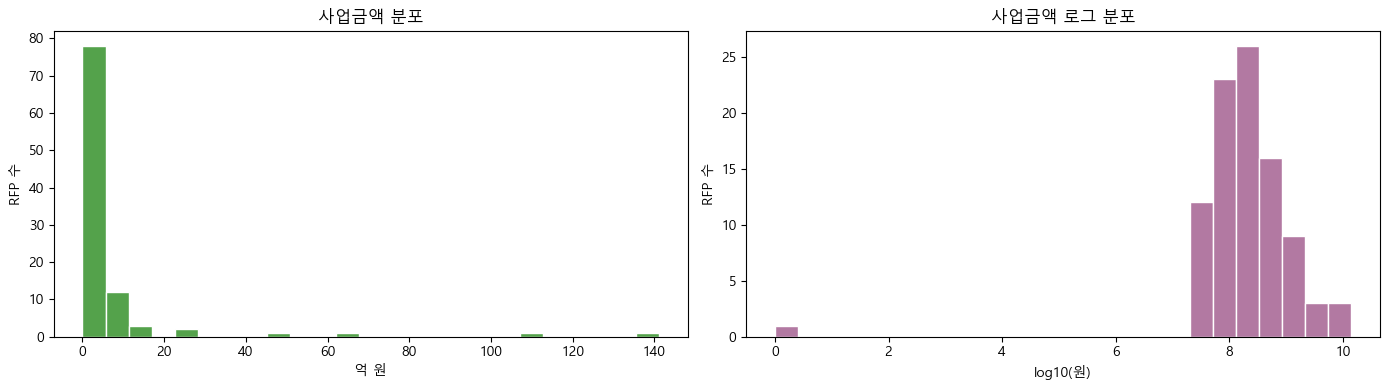

In [8]:
amount = eda[COL_AMOUNT].dropna()
amount_stats = amount.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).to_frame("krw")
amount_stats["100m_krw"] = amount_stats["krw"] / 100_000_000
display(amount_stats)

top_amount = eda.sort_values(COL_AMOUNT, ascending=False)[
    [COL_TITLE, COL_ORG, COL_AMOUNT, COL_FILE_TYPE, "text_chars"]
].head(15).copy()
top_amount["budget_100m_krw"] = top_amount[COL_AMOUNT] / 100_000_000
display(top_amount.drop(columns=[COL_AMOUNT]))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
(eda[COL_AMOUNT] / 100_000_000).plot(kind="hist", bins=25, ax=axes[0], color="#54A24B", edgecolor="white")
axes[0].set_title("사업금액 분포")
axes[0].set_xlabel("억 원")
axes[0].set_ylabel("RFP 수")

positive_amount = eda.loc[eda[COL_AMOUNT] > 0, COL_AMOUNT].dropna()
np.log10(positive_amount).plot(kind="hist", bins=25, ax=axes[1], color="#B279A2", edgecolor="white")
axes[1].set_title("사업금액 로그 분포")
axes[1].set_xlabel("log10(원)")
axes[1].set_ylabel("RFP 수")
plt.tight_layout()

## 6. 공고일과 입찰 마감일 분석

공개 일자, 입찰 시작일, 입찰 마감일을 기준으로 월별 공고 수와 공개 후 마감까지의 기간을 확인합니다.

공고일과 입찰 마감일 기준으로 일정 분포와 기간을 살펴봅니다.

,공개 일자,입찰 참여 시작일,입찰 참여 마감일,bid_window_days,publish_to_deadline_days
count,100,74,92,74.00,92.00
mean,2024-07-15 12:22:21.520000,2024-07-26 06:35:08.108108,2024-08-14 21:30:39.130434,9.72,15.10
min,2021-10-08 00:00:00,2024-02-21 10:00:00,2024-02-26 10:00:00,0.04,0.06
25%,2024-05-18 16:35:16.500000,2024-05-24 10:15:00,2024-05-31 06:45:00,4.00,11.00
50%,2024-06-18 16:30:01,2024-06-18 15:30:00,2024-07-02 15:00:00,7.08,12.03
75%,2024-10-17 21:42:36.250000,2024-10-13 16:00:00,2024-11-06 09:45:00,12.39,18.48
max,2025-02-11 13:32:46,2025-02-11 14:00:00,2025-03-10 11:00:00,45.71,45.86
std,NaN,NaN,NaN,9.23,8.92


,공개 일자,notice_count
0,2021-10-31,1
1,2021-11-30,0
2,2021-12-31,0
3,2022-01-31,0
4,2022-02-28,0
5,2022-03-31,0
6,2022-04-30,0
7,2022-05-31,0
8,2022-06-30,0
9,2022-07-31,0


,사업명,발주 기관,공개 일자,입찰 참여 마감일,publish_to_deadline_days
54,한국어촌어항공단 경영관리시스템(ERP·GW) 기능 고도화 용역,한국어촌어항공단,2024-05-30 09:29:26,2024-05-30 11:00:00,0.06
64,네팔 수자원관리 정보화사업-Pilot 시스템 구축용역,한국농어촌공사,2024-05-31 13:21:40,2024-05-31 17:00:00,0.15
55,2세대 전자조달시스템 기반구축사업,한국생산기술연구원,2024-05-30 11:00:23,2024-05-30 15:00:00,0.17
5,전기안전 관제시스템 보안 모듈 개발 용역,한국전기안전공사,2025-01-08 09:45:32,2025-01-08 15:30:00,0.24
62,한국로봇산업진흥원 사업관리시스템 온라인평가 체계 구축,한국로봇산업진흥원,2024-12-10 15:18:22,2024-12-11 12:00:00,0.86
52,아태 사이버범죄 역량강화 허브(APC-HUB) 홈페이지 및 온라인 교육시스템 고도화 2차사업,대검찰청,2024-05-30 10:20:19,2024-05-31 12:00:00,1.07
61,평택시 강소형 스마트시티 AI 기반의 영상감시 시스템 및 홍수감시 시스템 연동 개발,케빈랩 주식회사,2024-12-10 17:16:26,2024-12-16 11:00:00,5.74
37,"정읍체육트레이닝센터 통합운영관리시스템 구축 용역(협상에의한계약,긴급)",전북특별자치도 정읍시,2024-04-02 15:19:35,2024-04-09 17:00:00,7.07
76,[혁신-국고] 남서울대학교 스마트 정보시스템 활성화(학사행정 암호화) 개발 용역 입찰,남서울대학교,2024-10-16 09:43:43,2024-10-23 14:00:00,7.18
83,실손보험 청구 전산화 시스템 구축 사업,사단법인 보험개발원,2024-03-19 13:47:26,2024-03-27 14:00:00,8.01


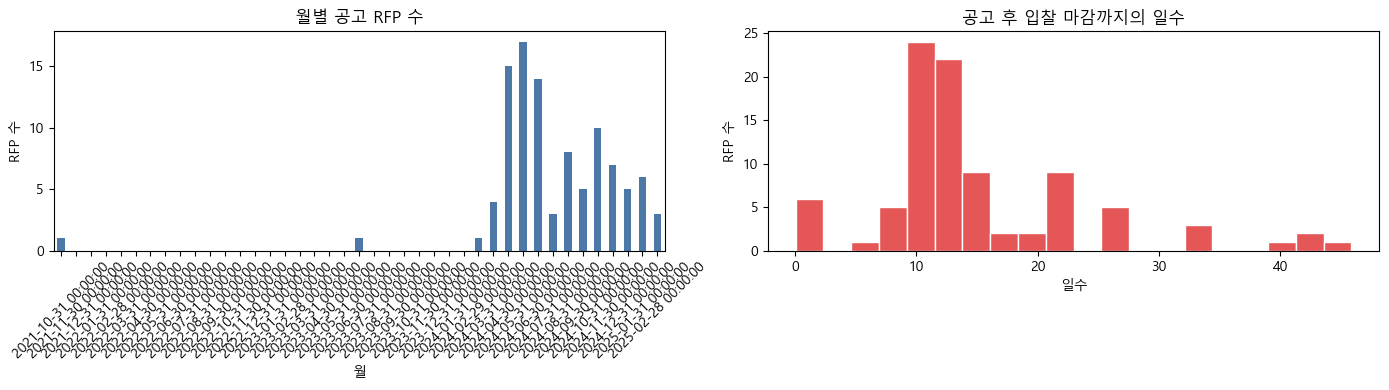

In [9]:
date_summary = eda[[COL_PUBLISHED_AT, COL_BID_START, COL_BID_END, "bid_window_days", "publish_to_deadline_days"]].describe()
display(date_summary)

monthly = eda.set_index(COL_PUBLISHED_AT).resample("ME").size().rename("notice_count")
display(monthly.reset_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
monthly.plot(kind="bar", ax=axes[0], color="#4C78A8")
axes[0].set_title("월별 공고 RFP 수")
axes[0].set_xlabel("월")
axes[0].set_ylabel("RFP 수")
axes[0].tick_params(axis="x", rotation=45)

eda["publish_to_deadline_days"].dropna().plot(kind="hist", bins=20, ax=axes[1], color="#E45756", edgecolor="white")
axes[1].set_title("공고 후 입찰 마감까지의 일수")
axes[1].set_xlabel("일수")
axes[1].set_ylabel("RFP 수")
plt.tight_layout()

display(
    eda.sort_values("publish_to_deadline_days")[[COL_TITLE, COL_ORG, COL_PUBLISHED_AT, COL_BID_END, "publish_to_deadline_days"]].head(10)
)

## 7. 텍스트 길이와 추출 품질

요약과 본문 텍스트 길이를 확인하여 문서 추출 품질을 빠르게 평가합니다. 본문 길이가 지나치게 짧은 문서는 파일 파싱 실패 가능성이 있습니다.

요약과 본문 텍스트 길이를 비교해 추출 품질을 점검합니다.

,count,mean,std,min,10%,25%,50%,75%,90%,max
title_chars,100.00,30.10,10.09,12.00,18.00,21.75,29.00,35.25,44.20,65.00
summary_chars,100.00,269.21,73.04,142.00,195.60,220.50,249.50,297.25,370.80,524.00
text_chars,100.00,"3,843.53","3,692.59",89.00,603.90,"1,198.00","2,583.00","5,842.00","7,675.20","18,335.00"
file_size_mb,100.00,1.63,2.61,0.14,0.28,0.53,0.92,1.54,3.75,22.99


,사업명,발주 기관,파일형식,file_size_mb,text_chars,path
34,모바일오피스 시스템 고도화 용역(총체 및 1차),한국철도공사 (용역),hwp,1.33,18335,data\raw\files\한국철도공사 (용역)_모바일오피스 시스템 고도화 용역(총체 및 1차).hwp
72,우즈벡-키르기즈스탄 기후변화대응 스마트 관개시스템 구축사업,사단법인아시아물위원회사무국,hwp,4.57,18039,data\raw\files\사단법인아시아물위원회사무국_우즈벡-키르기즈스탄 기후변화대응 스.hwp
55,2세대 전자조달시스템 기반구축사업,한국생산기술연구원,hwp,1.28,17414,data\raw\files\한국생산기술연구원_2세대 전자조달시스템 기반구축사업.hwp
33,2024년 버스정보시스템 확대 구축 및 기능개선 용역,울산광역시,hwp,0.65,15856,data\raw\files\울산광역시_2024년 버스정보시스템 확대 구축 및 기능개선 용역.hwp
21,의료기기산업 종합정보시스템(정보관리기관) 기능개선 사업,한국보건산업진흥원,hwp,0.79,9007,data\raw\files\한국보건산업진흥원_의료기기산업 종합정보시스템(정보관리기관) 기능.hwp
83,실손보험 청구 전산화 시스템 구축 사업,사단법인 보험개발원,hwp,3.74,8771,data\raw\files\사단법인 보험개발원_실손보험 청구 전산화 시스템 구축 사업.hwp
81,한국원자력연구원 선량평가시스템 고도화,한국원자력연구원,hwp,1.44,8669,data\raw\files\한국원자력연구원_한국원자력연구원 선량평가시스템 고도화.hwp
61,평택시 강소형 스마트시티 AI 기반의 영상감시 시스템 및 홍수감시 시스템 연동 개발,케빈랩 주식회사,hwp,1.02,8563,data\raw\files\케빈랩 주식회사_평택시 강소형 스마트시티 AI 기반의 영상감시 시스템 .hwp
67,국가교육과정정보센터(NCIC) 시스템 운영 및 개선,한국교육과정평가원,hwp,0.36,8557,data\raw\files\한국교육과정평가원_국가교육과정정보센터(NCIC) 시스템 운영 및 개선.hwp
73,실시간통합연구비관리시스템(RCMS) 연계 모듈 변경 사업,광주과학기술원,hwp,0.58,7686,data\raw\files\광주과학기술원_실시간통합연구비관리시스템(RCMS) 연계 모듈 변경 사업.hwp


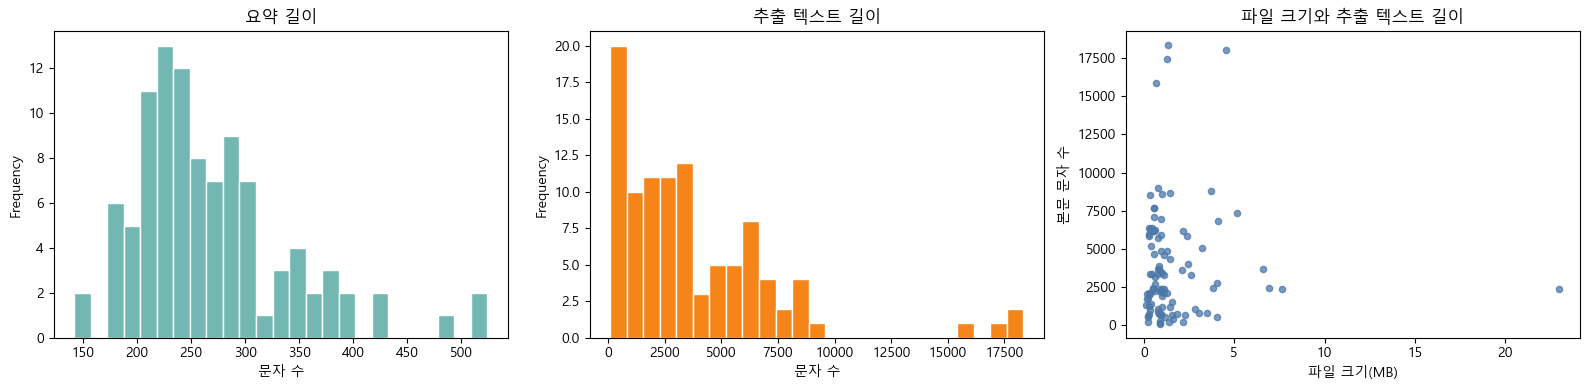

In [10]:
length_cols = ["title_chars", "summary_chars", "text_chars", "file_size_mb"]
display(eda[length_cols].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).T)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
eda["summary_chars"].plot(kind="hist", bins=25, ax=axes[0], color="#72B7B2", edgecolor="white")
axes[0].set_title("요약 길이")
axes[0].set_xlabel("문자 수")

eda["text_chars"].plot(kind="hist", bins=25, ax=axes[1], color="#F58518", edgecolor="white")
axes[1].set_title("추출 텍스트 길이")
axes[1].set_xlabel("문자 수")

eda.plot.scatter(x="file_size_mb", y="text_chars", ax=axes[2], alpha=0.75, color="#4C78A8")
axes[2].set_title("파일 크기와 추출 텍스트 길이")
axes[2].set_xlabel("파일 크기(MB)")
axes[2].set_ylabel("본문 문자 수")
plt.tight_layout()

long_docs = eda.sort_values("text_chars", ascending=False)[
    [COL_TITLE, COL_ORG, COL_FILE_TYPE, "file_size_mb", "text_chars", "path"]
].head(10)
display(long_docs)

## 8. 간단한 빈출어 분석

정규식 기반 토큰화만 사용하므로 한국어 형태소 분석기 수준의 정밀도는 없습니다. 더 정교한 한국어 NLP가 필요하면 이후 `kiwipiepy`, `konlpy`, Mecab 등을 추가하는 것이 좋습니다.

간단한 토큰화와 불용어 제거로 제목, 요약, 본문 빈출어를 계산합니다.

In [11]:
# 불용어에는 RFP에서 자주 등장하는 일반 용어를 포함합니다.
STOPWORDS = {
    "사업", "제안", "요청", "요청서", "용역", "시스템", "구축", "개발", "운영", "관리", "기능", "개선",
    "및", "등", "위한", "관련", "본", "본사업", "대상", "수행", "업무", "내용", "기관", "통해",
    "대한", "있는", "하여", "한다", "추진", "계획", "지원", "서비스", "정보", "데이터", "사용", "제공",
    "the", "and", "for", "with", "from", "this", "that",
}

TOKEN_PATTERN = re.compile(r"[가-힣A-Za-z0-9+#.]{2,}")

def tokenize(text: str) -> list[str]:
    tokens = TOKEN_PATTERN.findall(str(text).lower())
    return [tok for tok in tokens if tok not in STOPWORDS and not tok.isdigit()]

def term_frequency(series: pd.Series, top_n: int = 30) -> pd.DataFrame:
    counter = Counter()
    for text in series.fillna(""):
        counter.update(tokenize(text))
    return pd.DataFrame(counter.most_common(top_n), columns=["token", "count"])

title_terms = term_frequency(eda[COL_TITLE], 30)
summary_terms = term_frequency(eda[COL_SUMMARY], 30)
text_terms = term_frequency(eda[COL_TEXT], 30)

display(title_terms.head(20))
display(summary_terms.head(20))
display(text_terms.head(20))

,token,count
0,고도화,16
1,2024년,13
2,기능개선,11
3,긴급,7
4,정보시스템,7
5,재공고,7
6,차세대,5
7,홈페이지,5
8,구축사업,4
9,수립,4


,token,count
0,기대효과,70
1,추진배경,67
2,사업범위,65
3,추진목표,58
4,강화,58
5,필요,46
6,향상,39
7,사용자,36
8,고도화,36
9,사업개요,36


,token,count
0,요구사항,1093
1,1.,494
2,2.,464
3,제안서,456
4,3.,375
5,4.,269
6,서식,237
7,현황,217
8,분석,208
9,테스트,195


제목, 요약, 본문에서 자주 등장하는 단어를 그래프로 비교합니다.

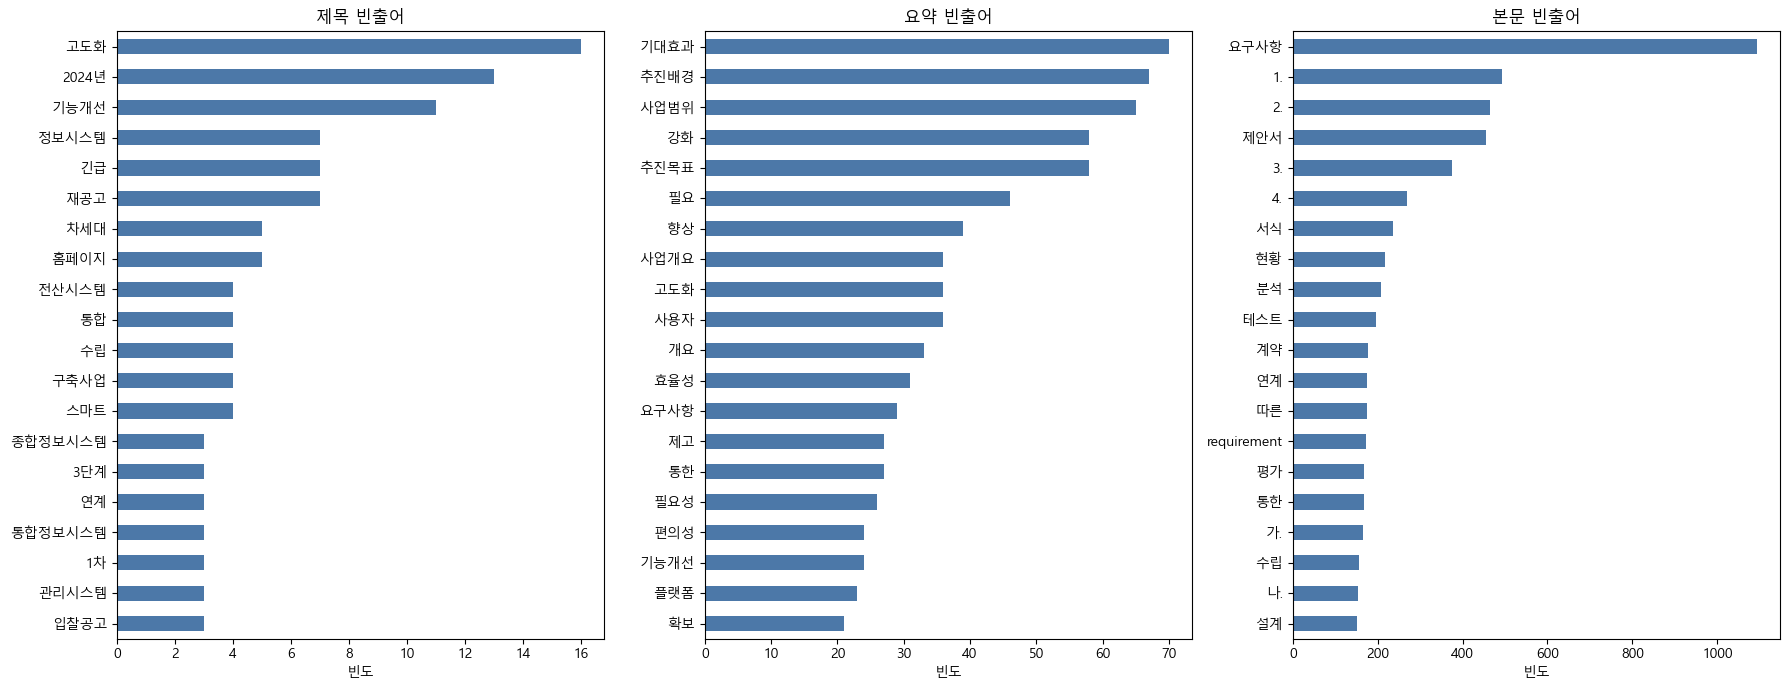

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, terms, title in zip(
    axes,
    [title_terms.head(20), summary_terms.head(20), text_terms.head(20)],
    ["제목 빈출어", "요약 빈출어", "본문 빈출어"],
):
    terms.sort_values("count").plot(kind="barh", x="token", y="count", legend=False, ax=ax, color="#4C78A8")
    ax.set_title(title)
    ax.set_xlabel("빈도")
    ax.set_ylabel("")
plt.tight_layout()

## 9. RFP 업무 유형 키워드 그룹

검색 필터, 검색 품질 평가, 메타데이터 보강에 사용할 수 있도록 간단한 업무 유형 태그를 만듭니다.

업무 유형별 키워드 그룹을 정의하고 문서별 포함 여부를 계산합니다.

,keyword_group,rfp_count
0,new_build,95
1,operation_maintenance,82
2,data_db,82
3,security_auth,81
4,enhancement,81
5,education_lms,50
6,cloud_infra,49
7,homepage_portal,47
8,ai_intelligent,34
9,gis_spatial,23


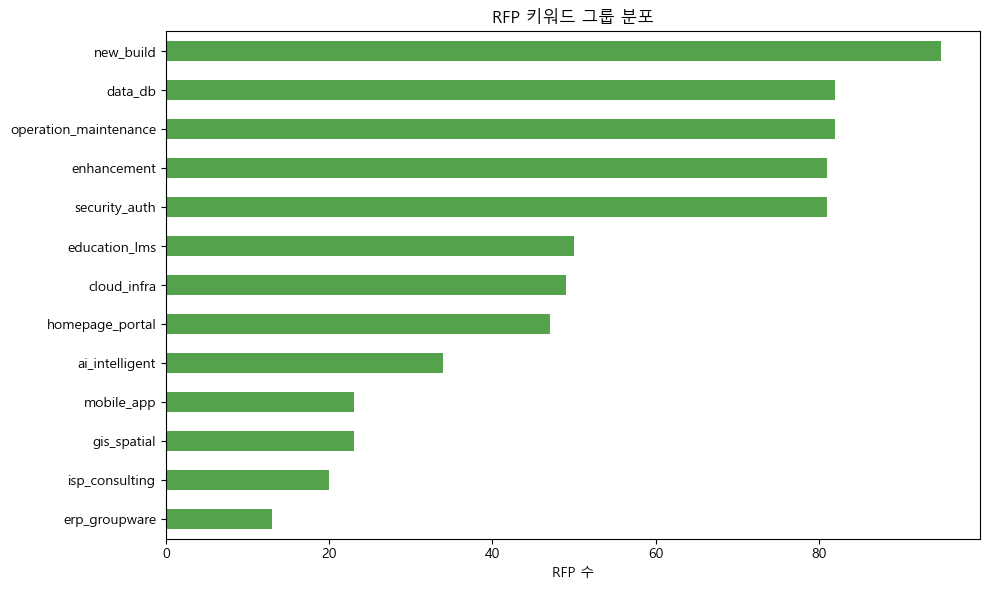

In [13]:
KEYWORD_GROUPS = {
    "new_build": ["구축", "신규", "개발", "재구축"],
    "operation_maintenance": ["운영", "유지보수", "위탁운영", "운영지원"],
    "enhancement": ["고도화", "개선", "기능개선", "개편"],
    "isp_consulting": ["ISP", "ISMP", "정보화전략", "컨설팅", "사전타당성"],
    "ai_intelligent": ["AI", "인공지능", "지능형", "영상감시"],
    "data_db": ["데이터", "DB", "아카이브", "통계", "분석"],
    "security_auth": ["보안", "인증", "접근성", "개인정보"],
    "cloud_infra": ["클라우드", "인프라", "서버", "네트워크", "DR", "재해복구"],
    "erp_groupware": ["ERP", "그룹웨어", "경영정보", "인사정보"],
    "homepage_portal": ["홈페이지", "포털", "플랫폼", "온라인서비스"],
    "mobile_app": ["모바일", "앱", "어플", "오피스"],
    "gis_spatial": ["GIS", "지도", "공간", "디지털트윈"],
    "education_lms": ["LMS", "학습", "교육", "이러닝", "학사"],
}

search_text = (
    eda[COL_TITLE].fillna("") + "\n" +
    eda[COL_SUMMARY].fillna("") + "\n" +
    eda[COL_TEXT].fillna("")
)

keyword_matrix = pd.DataFrame(index=eda.index)
for group, keywords in KEYWORD_GROUPS.items():
    pattern = "|".join(re.escape(k.lower()) for k in keywords)
    keyword_matrix[group] = search_text.str.lower().str.contains(pattern, regex=True, na=False)

keyword_counts = keyword_matrix.sum().sort_values(ascending=False).rename("rfp_count").reset_index()
keyword_counts.columns = ["keyword_group", "rfp_count"]
display(keyword_counts)

fig, ax = plt.subplots(figsize=(10, 6))
keyword_counts.sort_values("rfp_count").plot(kind="barh", x="keyword_group", y="rfp_count", legend=False, ax=ax, color="#54A24B")
ax.set_title("RFP 키워드 그룹 분포")
ax.set_xlabel("RFP 수")
ax.set_ylabel("")
plt.tight_layout()

문서별 키워드 그룹 결과를 주요 메타데이터와 함께 확인합니다.

In [14]:
eda_keywords = eda[[COL_TITLE, COL_ORG, COL_AMOUNT, COL_FILE_TYPE, "text_chars", "path"]].copy()
eda_keywords["keyword_groups"] = keyword_matrix.apply(lambda row: ", ".join(row.index[row]), axis=1)
eda_keywords["budget_100m_krw"] = eda_keywords[COL_AMOUNT] / 100_000_000

display(eda_keywords.sort_values("text_chars", ascending=False).head(20))

,사업명,발주 기관,사업 금액,파일형식,text_chars,path,keyword_groups,budget_100m_krw
34,모바일오피스 시스템 고도화 용역(총체 및 1차),한국철도공사 (용역),0.00,hwp,18335,data\raw\files\한국철도공사 (용역)_모바일오피스 시스템 고도화 용역(총체 및 1차).hwp,"new_build, operation_maintenance, enhancement, ai_intelligent, data_db, security_auth, cloud_infra, homepage_portal,...",0.00
72,우즈벡-키르기즈스탄 기후변화대응 스마트 관개시스템 구축사업,사단법인아시아물위원회사무국,"5,031,000,000.00",hwp,18039,data\raw\files\사단법인아시아물위원회사무국_우즈벡-키르기즈스탄 기후변화대응 스.hwp,"new_build, operation_maintenance, enhancement, data_db, security_auth, cloud_infra, gis_spatial, education_lms",50.31
55,2세대 전자조달시스템 기반구축사업,한국생산기술연구원,"94,000,000.00",hwp,17414,data\raw\files\한국생산기술연구원_2세대 전자조달시스템 기반구축사업.hwp,"new_build, operation_maintenance, enhancement, ai_intelligent, data_db, security_auth, cloud_infra, homepage_portal,...",0.94
33,2024년 버스정보시스템 확대 구축 및 기능개선 용역,울산광역시,"986,945,000.00",hwp,15856,data\raw\files\울산광역시_2024년 버스정보시스템 확대 구축 및 기능개선 용역.hwp,"new_build, operation_maintenance, enhancement, isp_consulting, ai_intelligent, data_db, security_auth, cloud_infra, ...",9.87
21,의료기기산업 종합정보시스템(정보관리기관) 기능개선 사업,한국보건산업진흥원,"50,000,000.00",hwp,9007,data\raw\files\한국보건산업진흥원_의료기기산업 종합정보시스템(정보관리기관) 기능.hwp,"new_build, operation_maintenance, enhancement, isp_consulting, data_db, security_auth, cloud_infra, homepage_portal",0.50
83,실손보험 청구 전산화 시스템 구축 사업,사단법인 보험개발원,1.00,hwp,8771,data\raw\files\사단법인 보험개발원_실손보험 청구 전산화 시스템 구축 사업.hwp,"new_build, operation_maintenance, enhancement, ai_intelligent, data_db, security_auth, cloud_infra, homepage_portal,...",0.00
81,한국원자력연구원 선량평가시스템 고도화,한국원자력연구원,"46,600,000.00",hwp,8669,data\raw\files\한국원자력연구원_한국원자력연구원 선량평가시스템 고도화.hwp,"new_build, operation_maintenance, enhancement, ai_intelligent, data_db, security_auth, cloud_infra, homepage_portal,...",0.47
61,평택시 강소형 스마트시티 AI 기반의 영상감시 시스템 및 홍수감시 시스템 연동 개발,케빈랩 주식회사,"341,000,000.00",hwp,8563,data\raw\files\케빈랩 주식회사_평택시 강소형 스마트시티 AI 기반의 영상감시 시스템 .hwp,"new_build, operation_maintenance, enhancement, isp_consulting, ai_intelligent, data_db, security_auth, cloud_infra, ...",3.41
67,국가교육과정정보센터(NCIC) 시스템 운영 및 개선,한국교육과정평가원,"50,000,000.00",hwp,8557,data\raw\files\한국교육과정평가원_국가교육과정정보센터(NCIC) 시스템 운영 및 개선.hwp,"new_build, operation_maintenance, enhancement, data_db, security_auth, cloud_infra, homepage_portal, mobile_app, edu...",0.50
73,실시간통합연구비관리시스템(RCMS) 연계 모듈 변경 사업,광주과학기술원,"54,450,000.00",hwp,7686,data\raw\files\광주과학기술원_실시간통합연구비관리시스템(RCMS) 연계 모듈 변경 사업.hwp,"new_build, operation_maintenance, enhancement, ai_intelligent, data_db, security_auth, cloud_infra, erp_groupware, g...",0.54


## 10. 샘플 문서 확인

가장 긴 문서와 중앙값에 가까운 길이의 문서를 출력해 원문 텍스트가 제대로 추출되었는지 확인합니다.

가장 긴 문서와 평균적인 길이의 문서를 직접 출력해 추출 상태를 확인합니다.

In [15]:
def show_document_sample(idx: int, n_chars: int = 1200) -> None:
    row = eda.loc[idx]
    print("=" * 100)
    print(f"제목: {row[COL_TITLE]}")
    print(f"발주기관: {row[COL_ORG]}")
    print(f"사업금액: {row[COL_AMOUNT]:,.0f} KRW" if pd.notna(row[COL_AMOUNT]) else "사업금액: 결측")
    print(f"파일: {row[COL_FILE_NAME]} ({row.get('file_size_mb', np.nan):.2f} MB)")
    print(f"경로: {row.get('path', '')}")
    print("-" * 100)
    print(str(row[COL_TEXT])[:n_chars])

longest_idx = eda["text_chars"].idxmax()
median_idx = (eda["text_chars"] - eda["text_chars"].median()).abs().idxmin()
show_document_sample(longest_idx, 1500)
show_document_sample(median_idx, 1000)

제목: 모바일오피스 시스템 고도화 용역(총체 및 1차)
발주기관: 한국철도공사 (용역)
사업금액: 0 KRW
파일: 한국철도공사 (용역)_모바일오피스 시스템 고도화 용역(총체 및 1차).hwp (1.33 MB)
경로: data\raw\files\한국철도공사 (용역)_모바일오피스 시스템 고도화 용역(총체 및 1차).hwp
----------------------------------------------------------------------------------------------------
  
 
제안요청서
모바일오피스 시스템 고도화
 
2024. 8.
 
담당
디지털융합본부
(디지털기술TF)
처장 이규범
TEL: 042-615-5730
FAX: 02-361-8371
E-MAIL: mineandy77@korail.com
부장 이정민
TEL: 042-615-5733
대리 조서연  
TEL: 042-615-5746
한국철도공사
 
 1. 사업 개요	  -   	1
 2. 운영 현황	  -   	2
 3. 사업 내용	  -   	4
 4. 사업추진 계획	  -   	6
 5. 제안요청 내용	  -   	7
 6. 제안서 작성요령	  -   	99
 7. 제안서 평가 및 선정 안내	  -   	105
 8. 보안 준수사항	  -   	124
 9. 기타사항	  -   	136
 10. 별지서식 및 붙임	  -   	 141
 
1
사업 개요
  사업목적
   (모바일 업무지원 확대) 모바일오피스 사용량 증가에 따른 사용자 편의성, 처리속도 개선 및 기능 강화로 모바일 업무지원 확대
   (서비스 연속성 확보) 시스템 사용요구에 대한 부하 분산으로 원활하고 안정적인 업무지원 서비스 제공
  사업개요
   사 업 명 : 모바일오피스 시스템 고도화
    ※ 본 사업은 소프트웨어 진흥법 제43조, 같은 법 시행령 제35조 내지 제37조, 소프트웨어사업 계약 및 관리감독에 관한 지침 제5조, 제6조에 따라 SW사업 영향평가를 미리 실시한 사업임(붙임 1)
    ※

## 11. 표/그래프 포함 여부 확인

`data/raw_pdf`에 저장된 PDF를 직접 로드해 페이지별 표 후보와 이미지/도형 후보를 세어 문서별로 집계합니다. 표는 `pdfplumber.extract_tables()` 결과를 기준으로 하며, 그래프는 PDF 내 이미지/도형 객체를 통해 가능성을 확인합니다.

In [ ]:
from pathlib import Path
import importlib.util

RAW_PDF_DIR = PROJECT_ROOT / "data" / "raw_pdf"
pdf_paths = sorted(path for path in RAW_PDF_DIR.rglob("*.pdf") if path.is_file())

print(f"PDF 파일 수: {len(pdf_paths):,}")
print(f"분석 폴더: {RAW_PDF_DIR}")

if importlib.util.find_spec("pdfplumber") is None:
    print("pdfplumber가 설치되어 있지 않아 PDF 구조 분석을 건너뜁니다.")
    print("설치 명령: venv\\Scripts\\python.exe -m pip install pdfplumber")
    pdf_visual_audit = pd.DataFrame({"pdf_path": [str(path) for path in pdf_paths]})
    display(pdf_visual_audit.head(20))
else:
    import pdfplumber

    def audit_pdf_visuals(pdf_path: Path) -> dict:
        result = {
            "file_name": pdf_path.name,
            "pdf_path": str(pdf_path.relative_to(PROJECT_ROOT)),
            "page_count": 0,
            "table_count": 0,
            "image_count": 0,
            "curve_count": 0,
            "rect_count": 0,
            "pages_with_tables": [],
            "pages_with_visual_objects": [],
            "status": "ok",
            "message": "",
        }
        try:
            with pdfplumber.open(pdf_path) as pdf:
                result["page_count"] = len(pdf.pages)
                for page_number, page in enumerate(pdf.pages, start=1):
                    tables = page.extract_tables() or []
                    image_count = len(getattr(page, "images", []) or [])
                    curve_count = len(getattr(page, "curves", []) or [])
                    rect_count = len(getattr(page, "rects", []) or [])

                    if tables:
                        result["table_count"] += len(tables)
                        result["pages_with_tables"].append(page_number)

                    result["image_count"] += image_count
                    result["curve_count"] += curve_count
                    result["rect_count"] += rect_count
                    if image_count or curve_count or rect_count:
                        result["pages_with_visual_objects"].append(page_number)
        except Exception as exc:
            result["status"] = "failed"
            result["message"] = str(exc)
        return result

    pdf_visual_audit = pd.DataFrame([audit_pdf_visuals(path) for path in pdf_paths])
    if not pdf_visual_audit.empty:
        pdf_visual_audit["has_table"] = pdf_visual_audit["table_count"] > 0
        pdf_visual_audit["has_graph_hint"] = (
            pdf_visual_audit["image_count"]
            + pdf_visual_audit["curve_count"]
            + pdf_visual_audit["rect_count"]
        ) > 0
        pdf_visual_audit["visual_object_count"] = (
            pdf_visual_audit["image_count"]
            + pdf_visual_audit["curve_count"]
            + pdf_visual_audit["rect_count"]
        )
        pdf_visual_audit["pages_with_tables"] = pdf_visual_audit["pages_with_tables"].apply(lambda pages: ", ".join(map(str, pages[:20])))
        pdf_visual_audit["pages_with_visual_objects"] = pdf_visual_audit["pages_with_visual_objects"].apply(lambda pages: ", ".join(map(str, pages[:20])))

    visual_summary = pd.DataFrame({
        "metric": [
            "PDF 파일 수",
            "분석 성공 PDF 수",
            "분석 실패 PDF 수",
            "표가 감지된 PDF 수",
            "이미지/도형 객체가 감지된 PDF 수",
            "감지된 표 총 개수",
            "감지된 이미지 객체 총 개수",
            "감지된 곡선 객체 총 개수",
            "감지된 사각형 객체 총 개수",
        ],
        "count": [
            len(pdf_visual_audit),
            int((pdf_visual_audit["status"] == "ok").sum()),
            int((pdf_visual_audit["status"] == "failed").sum()),
            int(pdf_visual_audit["has_table"].sum()),
            int(pdf_visual_audit["has_graph_hint"].sum()),
            int(pdf_visual_audit["table_count"].sum()),
            int(pdf_visual_audit["image_count"].sum()),
            int(pdf_visual_audit["curve_count"].sum()),
            int(pdf_visual_audit["rect_count"].sum()),
        ],
    })

    print("PDF 원본 기반 표/그래프 후보 요약")
    display(visual_summary)

    display(
        pdf_visual_audit.sort_values(
            ["table_count", "visual_object_count", "page_count"],
            ascending=False,
        ).head(20)
    )

PDF 파일 수: 97
분석 폴더: c:\Users\jgi01\Desktop\codeit_project_2\data\raw_pdf
PDF 원본 기반 표/그래프 후보 요약


,metric,count
0,PDF 파일 수,97
1,분석 성공 PDF 수,97
2,분석 실패 PDF 수,0
3,표가 감지된 PDF 수,97
4,이미지/도형 객체가 감지된 PDF 수,97
5,감지된 표 총 개수,12542
6,감지된 이미지 객체 총 개수,4967
7,감지된 곡선 객체 총 개수,89922
8,감지된 사각형 객체 총 개수,161522


,file_name,pdf_path,page_count,table_count,image_count,curve_count,rect_count,pages_with_tables,pages_with_visual_objects,status,message,has_table,has_graph_hint,visual_object_count
12,고려대학교_차세대 포털·학사 정보시스템 구축사업.pdf,data\raw_pdf\고려대학교_차세대 포털·학사 정보시스템 구축사업.pdf,297,420,343,0,33221,"5, 6, 9, 11, 12, 13, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28","1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20",ok,,True,True,33564
24,그랜드코리아레저(주)_2024년도 GKL 그룹웨어 시스템 구축 용역.pdf,data\raw_pdf\그랜드코리아레저(주)_2024년도 GKL 그룹웨어 시스템 구축 용역.pdf,181,378,18,281,495,"1, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23","2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 21, 31, 32",ok,,True,True,794
8,경기도 평택시_2024년도 평택시 버스정보시스템(BIS) 구축사업.pdf,data\raw_pdf\경기도 평택시_2024년도 평택시 버스정보시스템(BIS) 구축사업.pdf,118,353,126,4,12231,"2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21","1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20",ok,,True,True,12361
6,KOICA 전자조달_[긴급] [지문] [국제] 우즈베키스탄 열린 의정활동 상하원 .pdf,data\raw_pdf\KOICA 전자조달_[긴급] [지문] [국제] 우즈베키스탄 열린 의정활동 상하원 .pdf,154,231,17,1711,1246,"1, 2, 7, 8, 9, 10, 11, 14, 15, 16, 17, 20, 23, 24, 25, 26, 27, 28, 29, 30","1, 2, 3, 6, 7, 8, 9, 12, 14, 15, 16, 17, 19, 20, 23, 25, 26, 27, 28, 29",ok,,True,True,2974
92,한국철도공사 (용역)_모바일오피스 시스템 고도화 용역(총체 및 1차).pdf,data\raw_pdf\한국철도공사 (용역)_모바일오피스 시스템 고도화 용역(총체 및 1차).pdf,181,222,115,8,10272,"4, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25","1, 2, 3, 4, 5, 7, 8, 9, 10, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23",ok,,True,True,10395
19,국립중앙의료원_(긴급)「2024년도 차세대 응급의료 상황관리시스템 구축.pdf,data\raw_pdf\국립중앙의료원_(긴급)「2024년도 차세대 응급의료 상황관리시스템 구축.pdf,63,216,26,2180,1001,"1, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22","1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20",ok,,True,True,3207
65,한국가스공사_[재공고]차세대 통합정보시스템(ERP) 구축.pdf,data\raw_pdf\한국가스공사_[재공고]차세대 통합정보시스템(ERP) 구축.pdf,48,209,1,0,1431,"2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21","1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20",ok,,True,True,1432
69,한국농어촌공사_네팔 수자원관리 정보화사업-Pilot 시스템 구축용역.pdf,data\raw_pdf\한국농어촌공사_네팔 수자원관리 정보화사업-Pilot 시스템 구축용역.pdf,58,197,2329,41375,1458,"1, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22","1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20",ok,,True,True,45162
0,(사)벤처기업협회_2024년 벤처확인종합관리시스템 기능 고도화 용역사업 .pdf,data\raw_pdf\(사)벤처기업협회_2024년 벤처확인종합관리시스템 기능 고도화 용역사업 .pdf,131,190,9,1815,2202,"1, 5, 6, 8, 9, 12, 13, 14, 15, 16, 17, 21, 22, 23, 24, 27, 28, 29, 30, 31","1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 16, 17, 19, 21, 22, 23",ok,,True,True,4026
74,한국사학진흥재단_대학재정정보시스템(기본재산 및 기채 사후관리) 고.pdf,data\raw_pdf\한국사학진흥재단_대학재정정보시스템(기본재산 및 기채 사후관리) 고.pdf,64,187,23,0,2323,"1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21","1, 3, 4, 5, 6, 8, 30, 33, 35, 36, 38, 39, 40, 41, 42, 44, 45, 46, 47, 48",ok,,True,True,2346


저장 완료: c:\Users\jgi01\Desktop\codeit_project_2\outputs\eda\pdf_table_graph_audit.csv


## 12. 다음 RAG 단계 메모

- 인덱스를 만들기 전에 메타데이터와 실제 파일의 매칭 결과를 확인합니다.
- 공고번호와 입찰 일정 결측치는 필수값이 아닌 선택 메타데이터 필터로 다루는 편이 안전합니다.
- 본문 길이가 지나치게 짧은 문서는 원본 파싱을 다시 평가합니다.
- 첫 청크는 요구사항, 평가기준, 사업범위, 일정, 제출물 같은 섹션 단위 분리를 우선 검토합니다.
- 벡터 DB 메타데이터로는 발주기관, 사업금액, 공고일과 마감일, 파일 형식, 키워드 그룹, 원본 경로가 유용합니다.